# FeuPy ROI Analysis

This notebook demonstrates how to configure and run a region-of-interest (ROI) analysis with FeuPy, inspect the resulting sources and datasets, and visualize the ROI map and spectral energy distributions (SEDs).

In [1]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst

import astropy.units as u
import gammapy
import matplotlib.pyplot as plt
from gammapy.utils.scripts import make_path

import feupy
from feupy.analysis.config import ROIAnalysisConfig
from feupy.analysis.core import ROIAnalysis
from feupy.catalogs import FEUPY_CATALOG_REGISTRY
from feupy.utils.coordinates import convert_skycoord_to_dict
from feupy.visualization import FEUPY_MPL_STYLE
from feupy.visualization.roimap import ROIMapPlotter
from feupy.visualization.sed import SEDPlotter
from feupy.visualization.styles.markers.plotting import (
    build_fp_kwargs,
    build_point_kwargs,
)

plt.style.use(make_path(FEUPY_MPL_STYLE))

print("FeuPy version:", feupy.__version__)
print("Gammapy version:", gammapy.__version__)

FeuPy version: 0.1.0
Gammapy version: 2.0


## Configure the region of interest

Select a target from the 1LHAASO catalog and define the ROI radius.

In [2]:
catalog = FEUPY_CATALOG_REGISTRY.get_cls("1LHAASO")()
target = catalog["1LHAASO J2002+3244u"]

target_position = target.position.icrs

config = ROIAnalysisConfig()
config.roi = convert_skycoord_to_dict(target_position)
config.roi.radius = 0.8 * u.deg

## Run the ROI analysis

In [3]:
analysis = ROIAnalysis(config)
analysis.run()

Setting logging config: {'level': 'INFO', 'filename': None, 'filemode': None, 'format': None, 'datefmt': None}
Loaded 19 catalogs.
Generating FluxPointsDataset.
Getting FluxPointsDataset.
Dataset created: FluxPointsDataset
-----------------

  Name                            : 4FGL J2002.3+3246 (4fgl) 

  Number of total flux points     : 8 
  Number of fit bins              : 6 

  Fit statistic type              : chi2
  Fit statistic value (-2 log(L)) : 4.94

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 2

  Component 0: SkyModel
  
    Name                      : 4FGL J2002.3+3246 (4fgl)
    Datasets names            : 4FGL J2002.3+3246 (4fgl)
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : 
    Temporal model type       : 
    Parameters:
      index                         :      2.615   +/-    0.14             
      amplitude                     :   1.68e-13   +/- 3.1e-14 1

## Inspect the results

In [4]:
print("Models in the ROI:")
print(analysis.datasets.models.names)

print("\nSources in the ROI:")
analysis.catalog

Models in the ROI:
['4FGL J2002.3+3246 (4fgl)', '1LHAASO J2002+3244u (1LHAASO) (KM2A)', '1LHAASO J2002+3244u (1LHAASO) (WCDA)']

Sources in the ROI:


index,source_name,source_label,catalog,ra,dec,separation,has_fp
,,,,deg,deg,deg,
int64,str19,str29,str7,float64,float64,float64,bool
0,4FGL J2002.3+3246,4FGL J2002.3+3246 (4fgl),4fgl,300.600,32.779,0.052,True
1,1LHAASO J2002+3244u,1LHAASO J2002+3244u (1LHAASO),1LHAASO,300.640,32.740,0.000,True
2,PSR J2002+3217,PSR J2002+3217 (psrcat),psrcat,300.518,32.288,0.463,False


In [5]:
sources = analysis.sources
datasets = analysis.datasets

## Configure plot markers

Create marker settings for catalog sources and flux-point datasets.

In [6]:
point_kwargs = build_point_kwargs(
    sources.labels,
    marker_size=5,
)

flux_point_kwargs = build_fp_kwargs(
    datasets.names,
    marker_size=5,
)

## Plot the ROI map

/home/phoenix/miniconda3/envs/feupy/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)


<WCSAxes: >

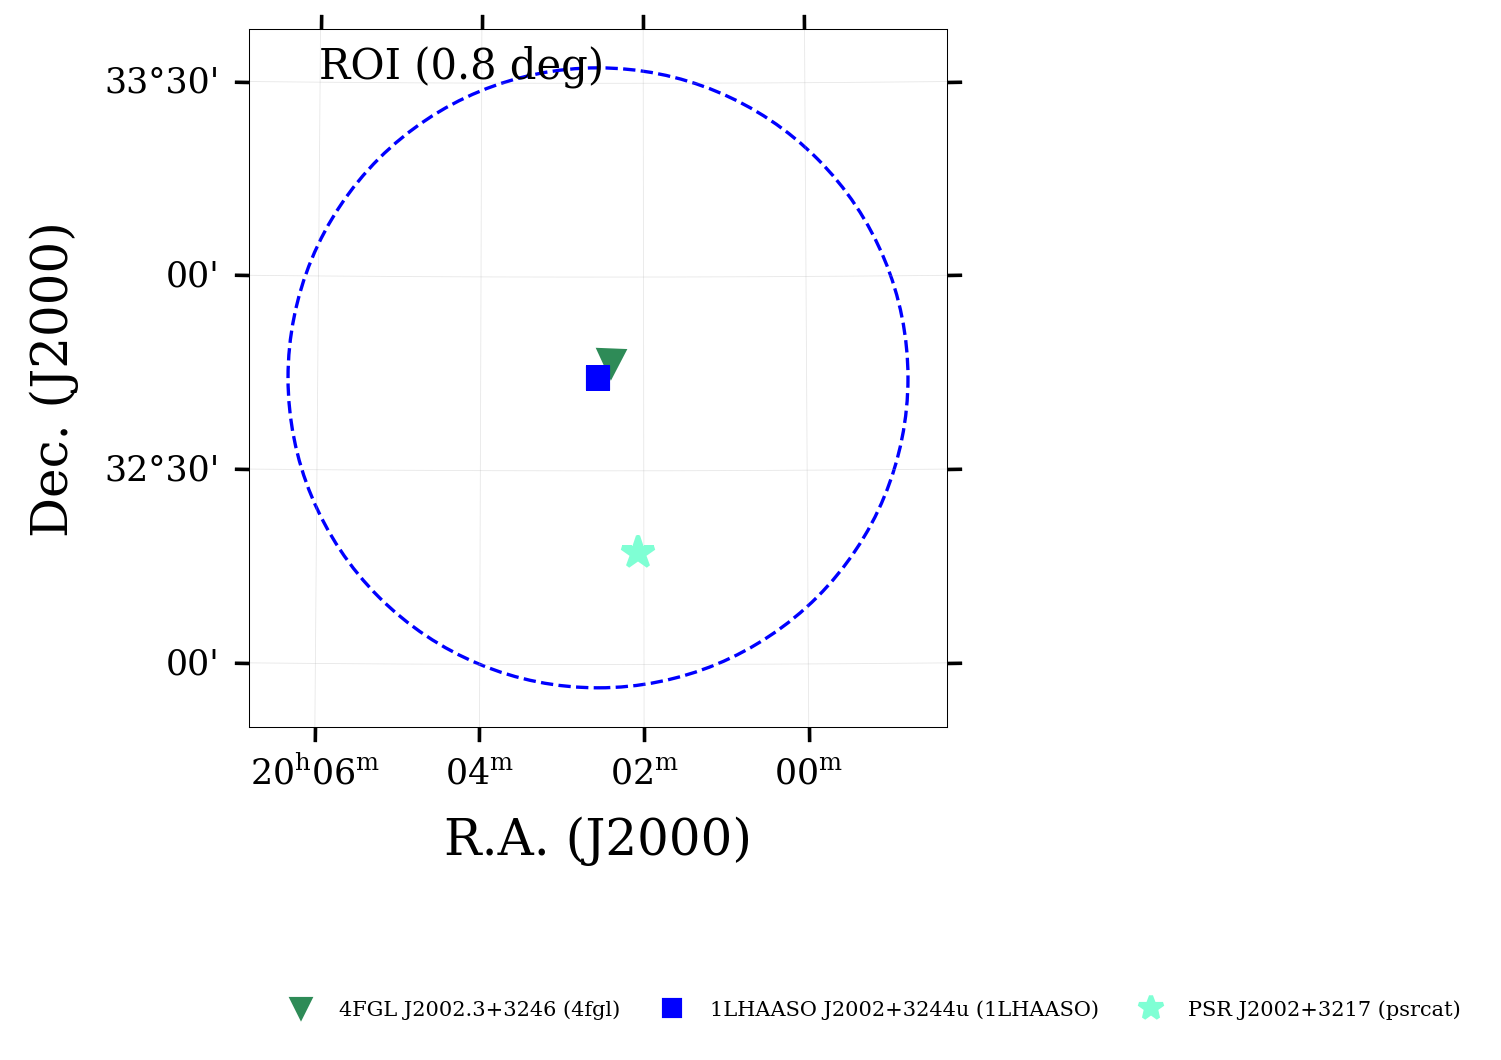

In [7]:
roi_plotter = ROIMapPlotter(
    center=target_position,
    radius=config.roi.radius,
)

roi_plotter.plot(
    sources=sources,
    ref_markers=point_kwargs,
)

## Plot the SED


The minimum and maximum energies are equal, so a small range will be created around the value: 49.99999999999999 TeV

The minimum and maximum energies are equal, so a small range will be created around the value: 3.0000000000000004 TeV


<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='$\\rm {E^{2}\\,\\Phi(E)\\, [erg\\,s^{-1}\\,cm^{-2}}$]'>

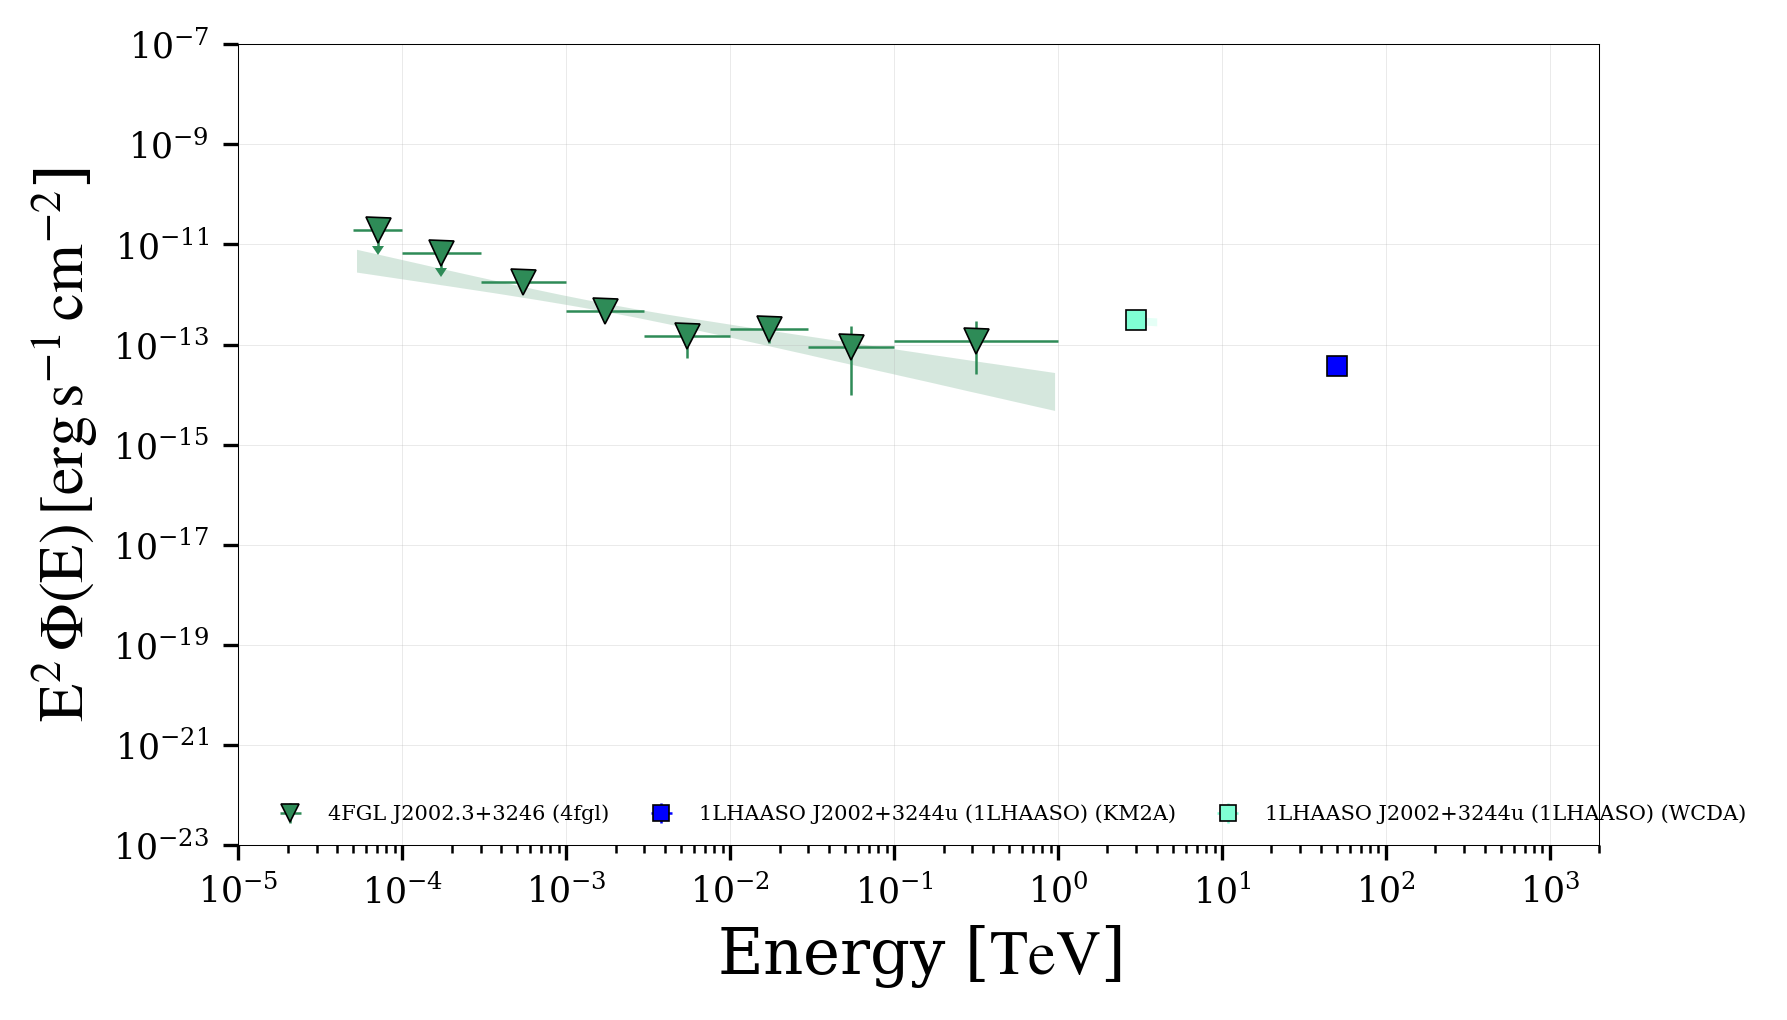

In [8]:
sed_plotter = SEDPlotter(datasets=datasets)

sed_plotter.plot(
    auto_energy_bounds=True,
    ref_markers=flux_point_kwargs,
)

## Summary

In [9]:
print("Datasets:")
print(datasets.names)

print("\nSources:")
print(sources.names)

Datasets:
['4FGL J2002.3+3246 (4fgl)', '1LHAASO J2002+3244u (1LHAASO) (KM2A)', '1LHAASO J2002+3244u (1LHAASO) (WCDA)']

Sources:
['4FGL J2002.3+3246', '1LHAASO J2002+3244u', 'PSR J2002+3217']
